# Pseudo-bulk matching for single-cell deconvolution

- Generate normalized pseudo-bulk profiles by summing/averaging sex-chimeric single-cell counts per condition.
- Normalize bulk RNA-seq profiles from chimeras and intersect genes with the single-cell data.
- For each condition, compute similarity between pseudo-bulk and bulk (Pearson, Spearman, cosine) to select the best-matching bulk reference sample used in scSemiProfiler deconvolution.

In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import pandas as pd
import scanpy as sc
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, spearmanr
seed = 10
np.random.seed(seed)
sc.settings.verbosity = 3
import scrublet as scr
sc.settings.set_figure_params(dpi=300, facecolor='white')

## Load single-cell and bulk data

Read 10x single-cell matrices (Ifnar1-/- Donor/mdxHost and Ifnar1+/+ Donor/mdxHost chimeras) and the bulk RNA-seq count matrix used for deconvolution.

In [ ]:
# IFNR
IFNR_sample = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/IFN/IFNR/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
# CD45-1
CD45_1_sample = sc.read_10x_mtx('/mnt/data/jiahui/CD14_mdx/IFN/CD45-1/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)   
for i,a in enumerate([IFNR_sample, CD45_1_sample]):
    a.obs['dataset']=str(i)
adata_merge = IFNR_sample.concatenate(CD45_1_sample, batch_key='sample')  
file_path = './reads_2nd bulk_yellow.txt'
bulk_data = pd.read_csv(file_path, sep='\t', index_col=0,header=1)
bulk_data = bulk_data.loc[:, "gene_name":]
bulk_data = bulk_data.loc[:, ~bulk_data.columns.str.contains('std')]
len(bulk_data)

In [3]:
im_bam_columns = bulk_data.columns[bulk_data.columns.str.contains(r'^im.*\.bam$')]
wm_bam_columns = bulk_data.columns[bulk_data.columns.str.contains(r'^wm.*\.bam$')]
bulk_data['im_bam_sum'] = bulk_data[im_bam_columns].sum(axis=1)
bulk_data['wm_bam_sum'] = bulk_data[wm_bam_columns].sum(axis=1)
bulk_data_filtered = bulk_data[(bulk_data['im_bam_sum'] > 0) & (bulk_data['wm_bam_sum'] > 0)]
bulk_data_filtered = bulk_data_filtered.drop(columns=['im_bam_sum', 'wm_bam_sum'])
len(bulk_data_filtered)


24495

## Build pseudo-bulk and intersect genes

Intersect genes between bulk and normalized sex-chimeric single-cell data, normalize counts, and construct pseudo-bulk expression profiles per condition.

In [ ]:
file_path = './reads_2nd bulk_yellow.txt'
bulk_data = pd.read_csv(file_path, sep='\t', index_col=0,header=1)
bulk_data = bulk_data.loc[:, "gene_name":]
bulk_data = bulk_data.loc[:, ~bulk_data.columns.str.contains('std')]
len(bulk_data)
bulk_genes = bulk_data['gene_name']
adata_merge = sc.read_h5ad('./sexchimeric_dataset_normalized.h5ad')
common_genes = set(bulk_genes) & set(adata_merge.var_names)
len(common_genes)

18626

In [8]:
bulk_data = bulk_data.drop_duplicates(subset='gene_name', keep='first')
bulk_data_filtered = bulk_data[bulk_data['gene_name'].isin(common_genes)].copy()
adata_merge_filtered = adata_merge[:, list(common_genes)].copy()
bulk_data_filtered.set_index('gene_name', inplace=True)
print(len(bulk_data_filtered),len(adata_merge_filtered))

18626 21572


In [ ]:
bulk_data_filtered = bulk_data_filtered.div(bulk_data_filtered.sum(axis=0), axis=1) * 1e4
bulk_data_filtered[bulk_data_filtered < 10] = 0
bulk_data_filtered = bulk_data_filtered.div(bulk_data_filtered.sum(axis=0), axis=1) * 1e4
sc.pp.normalize_total(adata_merge_filtered, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
scRNA_samples ='sexchimeric'
pseudo_bulk_dict = {}
adata_sample = adata_merge_filtered
pseudo_bulk_dict[scRNA_samples] = adata_sample.X.mean(axis=0).A1

In [15]:
pseudo_bulk_df = pd.DataFrame(pseudo_bulk_dict, index=adata_merge_filtered.var_names)
pseudo_bulk_df.head(10)

,sexchimeric
Nup188,0.003321
Tgfb1i1,0.001030
Wee1,0.005891
Tmed1,0.000000
Gm38250,0.000000
Slc7a15,0.000000
Cadps,0.000000
Klra10,0.000000
Glyr1,0.016749
Col4a1,0.038003


In [ ]:
### PCA: pseudo-bulk versus real bulk
#### Create AnnData objects for pseudo-bulk and real bulk, run PCA on the combined matrix, and visualize how closely pseudo-bulk replicates the bulk transcriptomes.
pseudo_bulk_adata = AnnData(pseudo_bulk_df.T)
pseudo_bulk_adata.var_names = pseudo_bulk_df.index
pseudo_bulk_adata.obs_names = pseudo_bulk_df.columns

""
sexchimeric


In [ ]:
non_zero_genes_real_bulk = (bulk_data_filtered > 0).sum(axis=0)
average_non_zero_genes_real_bulk = non_zero_genes_real_bulk.mean()
non_zero_genes_pseudo_bulk = (pseudo_bulk_df > 0).sum(axis=0)
average_non_zero_genes_pseudo_bulk = non_zero_genes_pseudo_bulk.mean()

computing PCA
    with n_comps=12


/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


    finished (0:00:00)


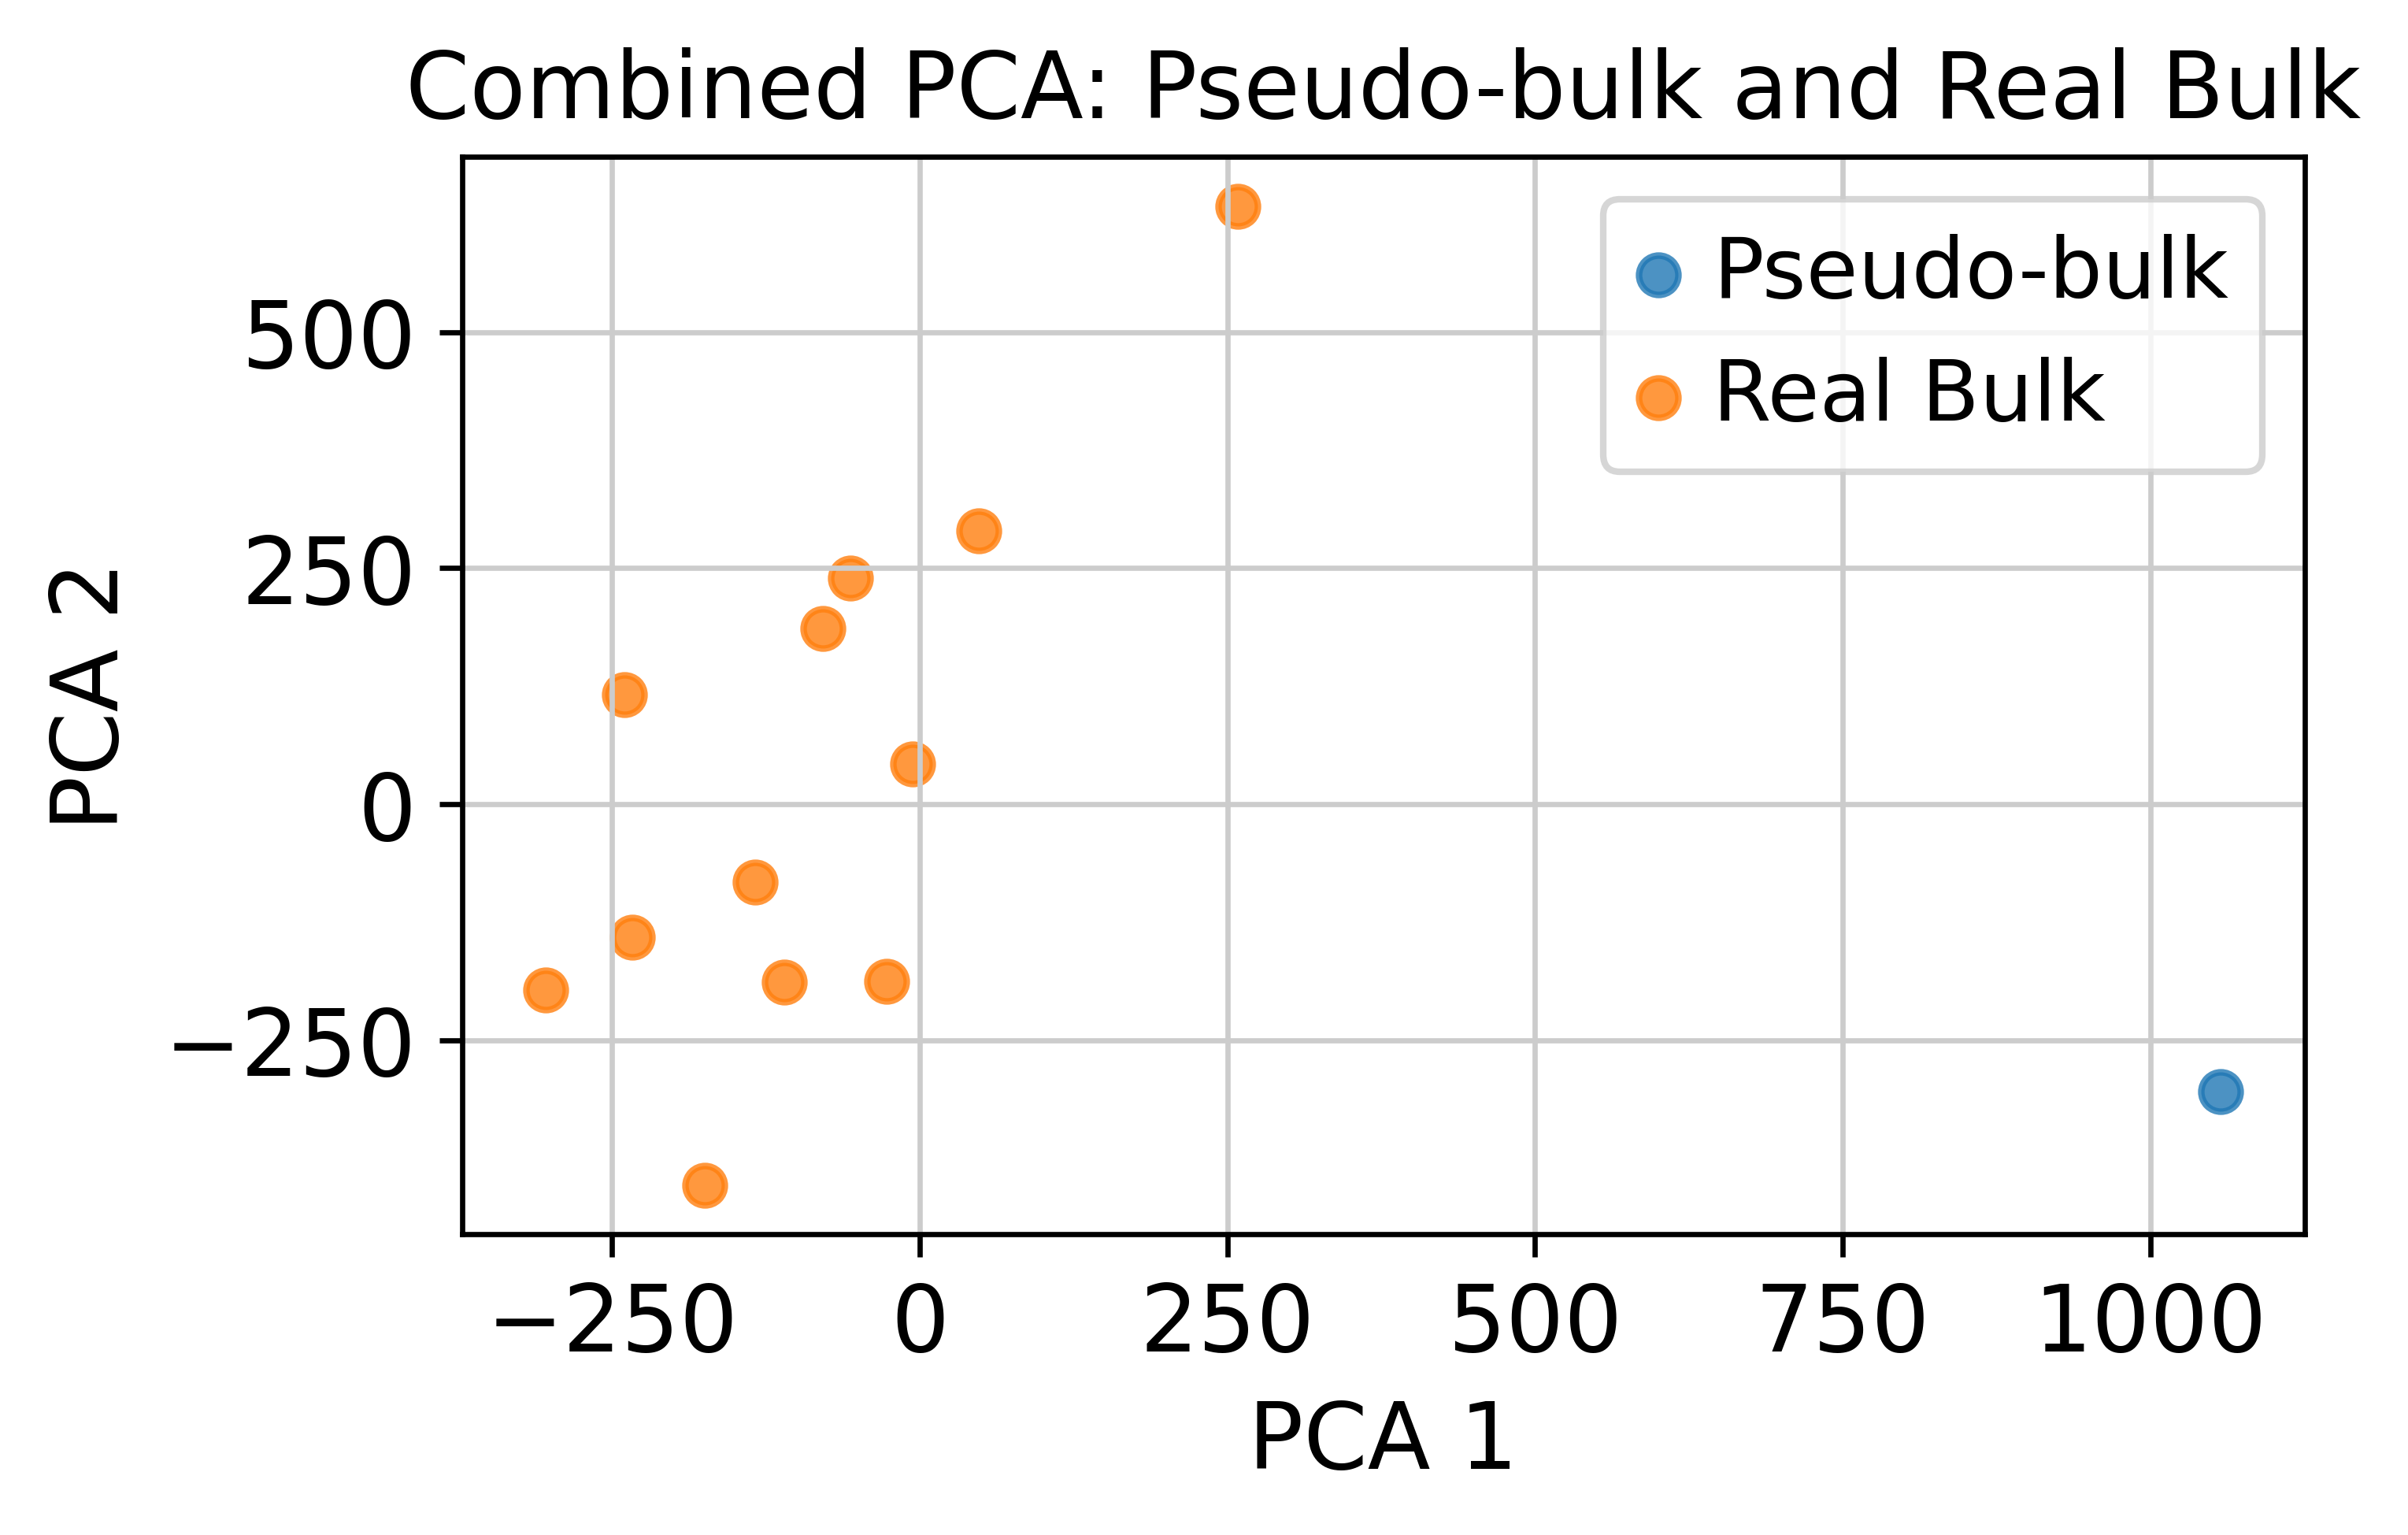

In [ ]:
real_bulk_adata = AnnData(bulk_data_filtered.T)
real_bulk_adata.var_names = bulk_data_filtered.index
real_bulk_adata.obs_names = bulk_data_filtered.columns
combined_adata = pseudo_bulk_adata.concatenate(real_bulk_adata)

sc.pp.pca(combined_adata)

plt.figure(figsize=(3, 3))
pca_result_combined = combined_adata.obsm["X_pca"]
plt.scatter(pca_result_combined[:pseudo_bulk_adata.n_obs, 0], pca_result_combined[:pseudo_bulk_adata.n_obs, 1], label="Pseudo-bulk", alpha=0.8)
plt.scatter(pca_result_combined[pseudo_bulk_adata.n_obs:, 0], pca_result_combined[pseudo_bulk_adata.n_obs:, 1], label="Real Bulk", alpha=0.8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.title("Combined PCA: Pseudo-bulk and Real Bulk")
plt.show()

In [ ]:
bulk_ifnr = bulk_data_filtered.filter(regex=r'^im.*\.bam$', axis=1)
bulk_cd45 = bulk_data_filtered.filter(regex=r'^wm.*\.bam$', axis=1)
common_genes_ifnr = pseudo_bulk_df.index.intersection(bulk_ifnr.index)
common_genes_cd45 = pseudo_bulk_df.index.intersection(bulk_cd45.index)
pseudo_bulk_ifnr = pseudo_bulk_df.loc[common_genes_ifnr]
pseudo_bulk_cd45 = pseudo_bulk_df.loc[common_genes_cd45]
bulk_ifnr = bulk_ifnr.loc[common_genes_ifnr]
bulk_cd45 = bulk_cd45.loc[common_genes_cd45]
def calculate_correlations(pseudo_bulk, bulk_data):
    correlations = {'pearson': [], 'spearman': [], 'cosine_distance': []}
    for col in bulk_data.columns:
        bulk_col = bulk_data[col]
        pseudo_bulk = np.ravel(pseudo_bulk)
        
        # Pearson correlation
        pearson_corr = pearsonr(pseudo_bulk, bulk_col)[0]
        correlations['pearson'].append(pearson_corr)
        
        # Spearman correlation
        spearman_corr = spearmanr(pseudo_bulk, bulk_col)[0]
        correlations['spearman'].append(spearman_corr)
        
        # Cosine distance
        cosine_dist = cosine(pseudo_bulk, bulk_col)
        correlations['cosine_distance'].append(cosine_dist)
    
    return pd.DataFrame(correlations, index=bulk_data.columns)

correlation_ifnr = calculate_correlations(pseudo_bulk_ifnr, bulk_ifnr)
correlation_cd45 = calculate_correlations(pseudo_bulk_cd45, bulk_cd45)
print("IFNR-/- Correlations:")
print(correlation_ifnr)

print("\nCD45.1 Correlations:")
print(correlation_cd45)


IFNR-/- Correlations:
          pearson  spearman  cosine_distance
im1.bam  0.577535  0.129498         0.421096
im2.bam  0.540543  0.124206         0.458005
im3.bam  0.538522  0.131263         0.460225
im4.bam  0.513102  0.137523         0.485311
im5.bam  0.504636  0.122615         0.493915
im6.bam  0.550880  0.122458         0.447815
im7.bam  0.589199  0.124528         0.409595

CD45.1 Correlations:
          pearson  spearman  cosine_distance
wm1.bam  0.562041  0.125255         0.436504
wm2.bam  0.572250  0.123471         0.426528
wm3.bam  0.620436  0.125562         0.378394
wm4.bam  0.483290  0.131695         0.514971
wm5.bam  0.559866  0.124622         0.438728


In [ ]:
adata_transfer = sc.read_h5ad('./sex_chimeric_only_Macro.h5ad')
adata_normalized = sc.read_h5ad('./sexchimeric_dataset_normalized.h5ad')
adata_bulk = sc.read_h5ad('./Bulk_Rna_CD45_1.h5ad')
sc.pp.normalize_total(adata_bulk, target_sum=1e4)
genes_transfer = adata_transfer.var_names
genes_normalized = adata_normalized.var_names
genes_bulk = adata_bulk.var_names

extra_genes = {'Rpl35', 'Rps27rt', 'Rpl9-ps6', 'Rps27', 'Uba52', 
               'Lars2', 'Gm42418', 'Uty', 'Kdm5d', 'Eif2s3y', 'Ddx3y', 'Xist','Lgals3bp'}

common_genes = genes_transfer.intersection(genes_normalized).intersection(genes_bulk).union(extra_genes)
adata_normalized = adata_normalized[:, common_genes].copy()
adata_bulk = adata_bulk[:, common_genes].copy()
print(len(common_genes))

normalizing counts per cell
    finished (0:00:00)
1799


In [ ]:
# Use the bulk sample with highest similarity (e.g. wm3) as the matched reference ID for the single-cell sex-chimeric dataset
adata_normalized.obs['group'] = 'sexchimeric'
adata_normalized.obs['sample_ids'] = 'wm3'
if 'sample_ids' in adata_bulk.obs.columns:
    adata_bulk.obs['sample_ids'] = adata_bulk.obs['sample_ids'].str.replace('.bam', '')

/tmp/ipykernel_3821692/1507162648.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  adata_bulk.obs['sample_ids'] = adata_bulk.obs['sample_ids'].str.replace('.bam', '')


In [ ]:

adata_bulk.write('Bulk_Rna_CD45_1_filtered.h5ad', compression='gzip')
adata_normalized.write('./scRNA_sexchimeric_CD45_1_norm_filtered.h5ad', compression='gzip')
